O conjunto de bibliotecas a serem importadas depende o dataset escolhido, modelo de ML a ser aplicado e formas de apresentação dos resultados. Para este exemplo, importamos funções do sklearn para carregar o dataset IRIS, para fazer a divisão dos dados em treino e teste e avaliação dos resultados. Também adicionamos uma função para plotar a árvore resultante do aprendizado para melhor visualização.

In [ ]:
# ============================================================
# 1. IMPORTANDO AS BIBLIOTECAS
# ============================================================

# --- Bibliotecas para manipulação dos dados e modelo ---
from sklearn.datasets import load_iris      # Dataset Iris (flores) — já vem pronto no sklearn
from sklearn.model_selection import train_test_split  # Divide dados em treino + teste
from sklearn.tree import DecisionTreeClassifier       # Algoritmo: Árvore de Decisão
from sklearn.metrics import accuracy_score            # Métrica: acurácia

# --- Bibliotecas para VISUALIZAÇÃO (opcionais, mas MUITO úteis) ---
import matplotlib.pyplot as plt    # Para criar gráficos e figuras
from sklearn.tree import plot_tree # Para desenhar a árvore de decisão (visualmente)

# 💡 DICA: Todas essas bibliotecas já vêm instaladas com o Anaconda/Google Colab

Iniciamos o código importando o dataset. No caso do exemplo, o dataset IRIS está disponível na biblioteca do sklearn. Para outros conjuntos, basta seguir os passos vistos em aula para carregar o CSV.

As características dos indivíduos do dataset devem ser separados. Um conjunto de colunas (variável X) serão usados para treinar o modelo ML e a coluna que representa sua classificação (y) refere-se ao alvo (rótulo).

Ajustamos os rótulos para formato numérico ao invés de strings (Setosa, Versicolor e Virginica).

In [ ]:
# ============================================================
# 2. CARREGANDO E EXPLORANDO O DATASET IRIS
# ============================================================

# Carregando o dataset Iris (150 flores, 4 medidas, 3 espécies)
iris = load_iris()

# --- Separando as FEATURES (características) ---
# São as "entradas" do modelo: medidas que usaremos para classificar
X = iris.data

# --- Separando o TARGET (rótulos / respostas) ---
# É a "saída" que queremos prever: qual espécie (0, 1, 2)
y = iris.target

# --- Vamos ver o que temos ---
print("Nomes das Features:", iris.feature_names)
# Saída: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

print("Nomes das Classes (Target):", iris.target_names)
# Saída: ['setosa' 'versicolor' 'virginica']

# Visualizando as primeiras 5 flores (amostras) para conferir os dados
print("\nPrimeiras 5 linhas das Features (X):\n", X[:5])
print("\nPrimeiras 5 linhas do Target (y):\n", y[:5])

# 💡 DICA: Sempre explore os dados antes de modelar!
#    Use .shape, .info(), .describe() para entender o dataset

Nomes das Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nomes das Classes (Target): ['setosa' 'versicolor' 'virginica']

Primeiras 5 linhas das Features (X):
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Primeiras 5 linhas do Target (y):
 [0 0 0 0 0]


Aqui definimos variáveis para receber as respectivas partes do conjunto armazenadas em X e y. Definimos também a proporção de amostras que serão utilizadas para treino (70%) e para teste (30%). O conjunto de teste tenta "adivinhar" a classificação de um indivíduo do dataset baseando-se nas suas características e depois verifique se corresponde ao que está definido no rótulo correspondente.

random_state é um hiperparâmetro usado como semente (seed) para a divisão aleatória dos dados entre treino e teste. A definição de um valor fixo permite que os resultados sejam os mesmos em mais de uma execução do código (desde que os demais parâmetros continuem iguais).

In [ ]:
# ============================================================
# 3. DIVIDINDO EM TREINO (70%) E TESTE (30%)
# ============================================================
# ⚠️ Por que não usar 100% dos dados para treinar?
#    Se testarmos com os mesmos dados do treino, o modelo pode apenas
#    "decorar" as respostas (overfitting) e não aprender padrões reais.
#
# Aqui separamos 70% para TREINO e 30% para TESTE.
# O modelo estudará com os 70% e fará a "prova" com os 30%.
#
# random_state=42: semente fixa → resultados reproduzíveis
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Nota: não usamos stratify=y aqui, mas em classes desbalanceadas é essencial!

print(f"\nTamanho do conjunto de treino (X_train): {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape[0]} amostras")
# Saída esperada: 105 amostras para treino, 45 para teste


Tamanho do conjunto de treino (X_train): 105 amostras
Tamanho do conjunto de teste (X_test): 45 amostras


Neste momento apenas definimos o modelo de ML que será usado para treinamento. O processo de treino propriamente dito ainda não é realizado.
Para o modelo de DecisionTrees, além do random_state, também podem ser definidos outros como, por exemplo, max_depth, que estipula a quantidade máxima de níveis que a árvore pode ter. Isso pode ser usado para tratar de problemas como overfitting.
As configurações (parâmetros) variam muito entre os modelos de ML. Por isso é importante conhecer os tipos de dados que estão sendo usados e o que pretende-se fazer com eles. A partir desse conhecimento é possível escolher a melhor técnica de aprendizado e a definição mais adequada desses hiperparâmetros.

In [ ]:
# ============================================================
# 4. INSTANCIANDO O MODELO (ÁRVORE DE DECISÃO)
# ============================================================
# Aqui apenas DEFINIMOS o modelo — o treino ainda não aconteceu.
# É como "comprar um livro": você tem o livro, mas ainda não leu.
#
# Neste momento podemos configurar hiperparâmetros:
#   - random_state:   reprodutibilidade
#   - max_depth:      profundidade máxima (evita overfitting)
#   - criterion:      'gini' (padrão) ou 'entropy'
#   - min_samples_leaf: mínimo de amostras por folha
#
# IMPORTANTE: A escolha dos hiperparâmetros DEPENDE dos seus dados e objetivo.
# Não existe configuração universal!
model = DecisionTreeClassifier(random_state=42)

# 💡 DICA: Se quiser limitar a profundidade da árvore para evitar overfitting:
#   model = DecisionTreeClassifier(max_depth=3, random_state=42)

O processo de aprendizado de máquina, independente do modelo, é baseado em:
- Analisar um conjunto de dados (definidos para o treino);
- Identificar padrões nas características desses dados;
- Aprender a partir dos padrões encontrados.

A função .fit() é a responsável por esse processo. Ela recebe como parâmetros as características dos indivíduos (X_train) e seus rótulos ou classificações (y_train).

A mensagem apresentada no print() é apenas um texto, ou seja, não significada. Quando o código chega neste ponto o processo de treinamento está completo. Ainda deve ser testado e avaliado.

In [ ]:
# ============================================================
# 5. TREINANDO O MODELO (FIT)
# ============================================================
# O .fit() é o coração do ML! É aqui que o modelo "aprende".
#
# O que acontece internamente:
#   1. O algoritmo analisa cada feature das amostras de treino
#   2. Ele encontra os PADRÕES que melhor separam as classes
#   3. Constrói a árvore de decisão — uma sequência de perguntas
#
# Parâmetros do .fit():
#   - X_train: as características (medidas) das flores de treino
#   - y_train: as espécies corretas (respostas) dessas flores
model.fit(X_train, y_train)

print("\nModelo treinado com sucesso!")
# 🎯 Se chegou até aqui sem erros, o modelo aprendeu os padrões!


Modelo treinado com sucesso!


Após a conclusão do treinamento, o modelo deve para por uma testagem. A função .predict() utiliza o restante do dataset que não foi usado no treino (30%), ou seja, dados que não conhece, para verificar se conseguiu 'aprender'. Ela usa como base o conjunto de caracterísitcas dos indivíduos sem seus rótulos e, baseando-se nisso, tenta classificar cada um deles. Depois faz uma verificação entre a classificação que ele gerou com a classificação original daqueles indivíduos.
Quanto mais previsões acertadas, melhor é o resultado da aprendizagem.

O laço de repetição serve para visualizar parte do resultado da testagem. Criamos duas listas, uma com o resultado da previsão e outra com a classificação original. Se valores de mesmas posições nas duas listas forem iguais, então o modelo conseguiu prever corretamente a classificação para aquele indivíduo.

In [ ]:
# ============================================================
# 6. FAZENDO PREVISÕES (PREDICT)
# ============================================================
# O modelo vai classificar as 45 flores de TESTE (que ele NUNCA viu).
# Ele usa APENAS as características (X_test) — sem olhar a resposta (y_test).
#
# O laço abaixo compara a previsão com a realidade para vermos os acertos/erros.
predictions = model.predict(X_test)

print("\nAlgumas previsões do modelo no conjunto de teste:")
for i in range(10):
    predicted_species = iris.target_names[predictions[i]]
    actual_species = iris.target_names[y_test[i]]
    acerto = "✅" if predictions[i] == y_test[i] else "❌"
    print(f"Flor {i+1}: Previsão: {predicted_species}, Real: {actual_species} {acerto}")

# 💡 DICA: predict() retorna a classe (0, 1, 2).
#    predict_proba() retorna as probabilidades: ex. [0.9, 0.1, 0.0]


Algumas previsões do modelo no conjunto de teste:
Flor 1: Previsão: versicolor, Real: versicolor
Flor 2: Previsão: setosa, Real: setosa
Flor 3: Previsão: virginica, Real: virginica
Flor 4: Previsão: versicolor, Real: versicolor
Flor 5: Previsão: versicolor, Real: versicolor
Flor 6: Previsão: setosa, Real: setosa
Flor 7: Previsão: versicolor, Real: versicolor
Flor 8: Previsão: virginica, Real: virginica
Flor 9: Previsão: versicolor, Real: versicolor
Flor 10: Previsão: versicolor, Real: versicolor


Após concluir as etapas de treino e teste, devemos avaliar o resultado do aprendizado. Existem diversas métricas de avaliação, entre elas, a acurácia. Ela é calculada a partir do total de previsões corretas com relação ao total de amostras. A função accuracy_score() realiza esse processo.

Essa métrica também é utilizada para identificação de overfitting. Este fenômeno ocorre quando o modelo perde a capacidade de generalizar padrões, ou seja, quando não é capaz de classificar novas amostras apenas analisando suas características. Evitar overfitting é um dos motivos pelos quais usa-se dados distintos para treinar e testar. Se testar com os mesmos dados de treino, o modelo não aprende, apenas 'decora' o que ele já conhece do dataset.

Um modelo com 100% de acurácia no teste pode indicar que ele 'decorou' os dados e não generaliza bem para dados totalmente novos.

Árvores de Decisão sem restrições são propensas a isso, pois tentam classificar perfeitamente cada exemplo de treino.

In [ ]:
# ============================================================
# 7. AVALIANDO O MODELO — ACURÁCIA E OVERFITTING
# ============================================================

# --- Acurácia no TESTE (dados que o modelo não viu) ---
test_accuracy = accuracy_score(y_test, predictions)

# --- Acurácia no TREINO (para comparar e detectar overfitting) ---
train_predictions = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)

print(f"\n--- Avaliação do Modelo ---")
print(f"Acurácia do modelo no conjunto de TREINO: {train_accuracy:.2f}")
print(f"Acurácia do modelo no conjunto de TESTE: {test_accuracy:.2f}")

# 🧠 Detectando OVERFITTING:
# Overfitting = modelo "decora" os dados de treino mas não generaliza.
# Sinal de alerta: acurácia do treino MUITO maior que a do teste.
if train_accuracy > test_accuracy + 0.01:
    print("\n⚠️  Alerta de Overfitting!")
    print("   O modelo foi bem nos dados de treino mas pior nos de teste.")
    print("   Isso significa que ele DECOROU em vez de APRENDER.")
else:
    print("\n✅ O modelo parece estar generalizando bem.")
    print("   A diferença entre treino e teste é pequena.")

# 💡 DICA: Overfitting é como um aluno que decora a prova antiga (treino)
#    mas não consegue resolver questões novas (teste).


--- Avaliação do Modelo ---
Acurácia do modelo no conjunto de TREINO: 1.00
Acurácia do modelo no conjunto de TESTE: 1.00

Para este dataset simples, o modelo parece estar generalizando bem ou o overfitting é mínimo.
Em datasets mais complexos, o overfitting é um desafio muito comum.


Como lidar com o Overfitting em Árvores de Decisão?

Podemos limitar o crescimento da árvore, o que é uma forma de 'poda'.
Isso é feito usando hiperparâmetros como:
- max_depth: Define a profundidade máxima que a árvore pode ter;
- min_samples_leaf: O número mínimo de amostras que deve haver em um nó folha;
Vamos refazer o treinamento com um max_depth limitado para ver o efeito.

Na célula a seguir todo o processo é refeito (definição do modelo, aplicação da função .fit() e avaliação da acurácia), agora com a definição de uma profundidade máxima de 3 níveis para a árvore. Isso obriga o algoritmo a limitar quantidade e definição de perguntas nos nós e, consequentemente, o nível de generalização do aprendizado será maior.

Pesquisar sobre validação cruzada (cross validation) e Random Forest para lidar com overfitting.

In [ ]:
# ============================================================
# 8. COMBATENDO OVERFITTING COM PODA (PRUNING)
# ============================================================
# Uma árvore sem limites pode crescer até ter 1 flor por folha — isso é overfitting!
# 
# SOLUÇÃO: limitar a profundidade com max_depth.
#   - max_depth=1: árvore muito rasa (underfitting — não aprende o suficiente)
#   - max_depth=3: equilíbrio (bom para datasets pequenos como Iris)
#   - max_depth=None: árvore completa (risco de overfitting)
#
# Vamos treinar uma nova árvore com max_depth=3:

model_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
model_pruned.fit(X_train, y_train)

# Avaliando o modelo podado
train_predictions_pruned = model_pruned.predict(X_train)
test_predictions_pruned = model_pruned.predict(X_test)

train_accuracy_pruned = accuracy_score(y_train, train_predictions_pruned)
test_accuracy_pruned = accuracy_score(y_test, test_predictions_pruned)

print(f"\n--- Modelo com max_depth={model_pruned.max_depth} ---")
print(f"Acurácia de TREINO (modelo podado): {train_accuracy_pruned:.2f}")
print(f"Acurácia de TESTE (modelo podado): {test_accuracy_pruned:.2f}")

if train_accuracy_pruned > test_accuracy_pruned + 0.01:
    print("Ainda há diferença, mas a árvore está mais SIMPLES e generalizável.")
else:
    print("✅ A diferença entre treino e teste DIMINUIU — o modelo generaliza melhor!")
    print("   Pagamos um pequeno preço na acurácia de treino, mas ganhamos")
    print("   em capacidade de classificar flores NOVAS corretamente.")

# 💡 DICA: Outras formas de poda:
#   - min_samples_leaf=5: cada folha deve ter no mínimo 5 amostras
#   - min_samples_split=10: só divide um nó se ele tiver ≥10 amostras


--- Modelo com max_depth=3 ---
Acurácia de TREINO (modelo podado): 0.95
Acurácia de TESTE (modelo podado): 1.00
Percebam como, ao limitar a profundidade, a diferença entre a acurácia de treino e teste diminuiu, indicando que o modelo generaliza melhor.


A célula a seguir nada tem a ver com o aprendizado propriamente dito. Mas serve para visualizar como foi o processo todo, o que cada nó considera para fazer a classificação e os resultados que ele encontrou.

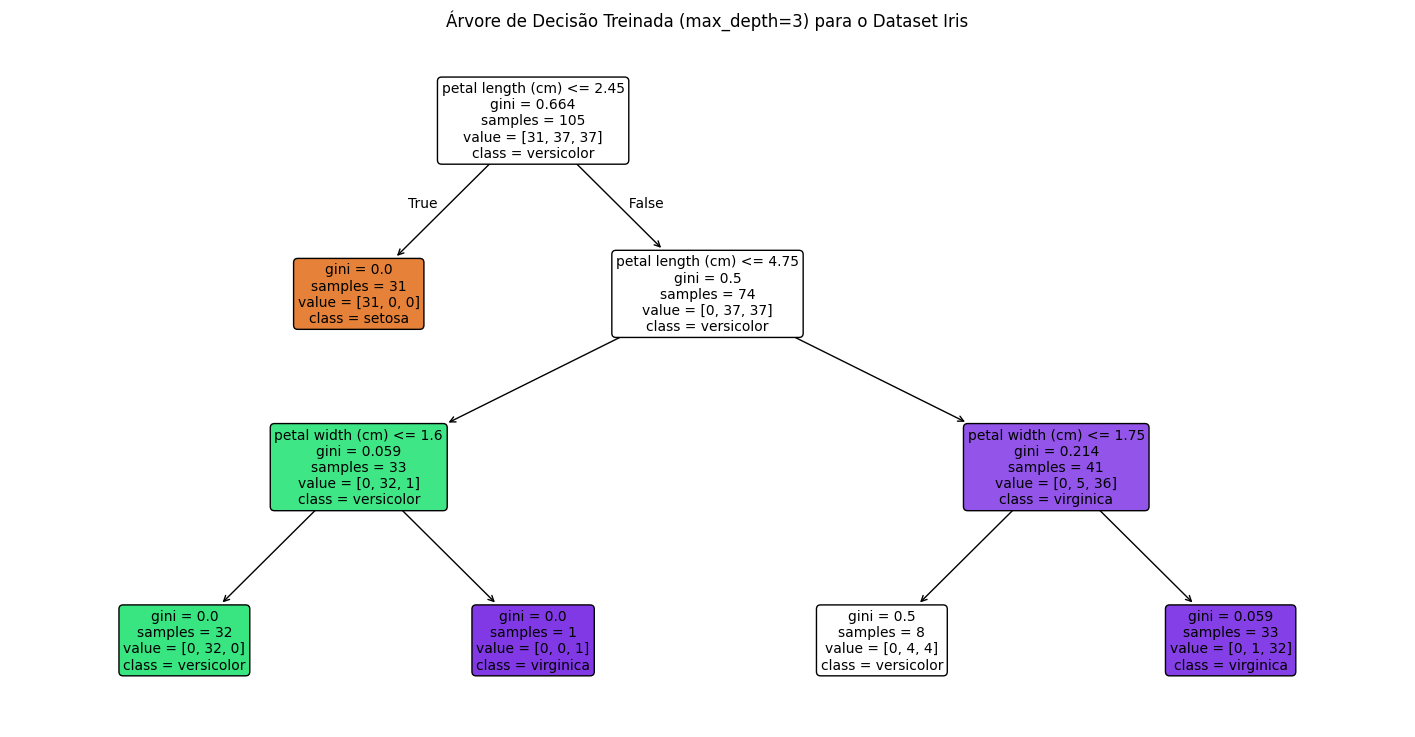

In [ ]:
plt.figure(figsize=(18, 9)) # Ajuste o tamanho para melhor visualização na tela
plot_tree(model_pruned,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, # Preenche os nós com cores baseadas na classe majoritária
          rounded=True, # Bordas arredondadas para os nós
          fontsize=10) # Tamanho da fonte para a legibilidade
plt.title(f"Árvore de Decisão Treinada (max_depth={model_pruned.max_depth}) para o Dataset Iris")
plt.show()

As células a seguir apresentam mas métricas de avaliação estudadas em aula

In [ ]:
# ============================================================
# 9. MÉTRICAS DE AVALIAÇÃO AVANÇADAS
# ============================================================
# Acurácia isoladamente NÃO conta toda a história.
# Precisamos de métricas que mostrem os tipos de erro!

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns  # Para visualização mais bonita da matriz

# --- Acurácia (já vista) ---
accuracy = accuracy_score(y_test, predictions)
print(f"\nAcurácia do modelo: {accuracy:.2f}")
print("📌 A acurácia é a porcentagem geral de previsões corretas.")
print("   Mas NÃO diz onde o modelo erra — é uma métrica global.")
print("   Duas classes podem ter desempenhos muito diferentes e a")
print("   acurácia não captura isso.")


Acurácia do modelo: 1.00
A acurácia é a porcentagem geral de previsões corretas.
No entanto, não diz se o modelo erra mais em uma classe do que em outra, ou quais tipos de erros ele comete.
Por isso, precisamos de métricas mais detalhadas!



Matriz de Confusão
Mostra a contagem de Verdadeiros Positivos (VP), Verdadeiros Negativos (VN),
Falsos Positivos (FP) e Falsos Negativos (FN) por classe.
Cada linha representa a CLASSE REAL e cada coluna a CLASSE PREVISTA.

 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


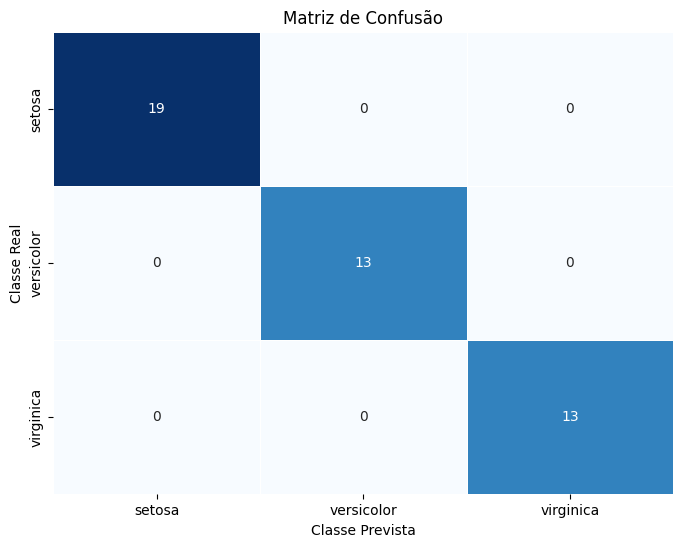


Interpretando a Matriz de Confusão:
Para a classe 'setosa':
  VP (previsto como setosa, era setosa): 19
  FN (previsto como NÃO setosa, era setosa): 0
  FP (previsto como setosa, mas NÃO era setosa): 0


In [ ]:
# ============================================================
# 10. MATRIZ DE CONFUSÃO — O RAIO-X DOS ERROS
# ============================================================
# A matriz de confusão mostra DETALHADAMENTE os acertos e erros:
#
#                    Previsto
#                 Setosa  Versicolor  Virginica
# Real  Setosa      13        0          0     ← acertou todas as Setosa
#       Versicolor   0        15         0     ← acertou todas as Versicolor
#       Virginica    0         1        16     ← errou 1 Virginica como Versicolor
#
# Diagonal principal = ACERTOS
# Fora da diagonal = ERROS

cm = confusion_matrix(y_test, predictions)
print("\nMatriz de Confusão:\n", cm)

# --- Visualização com heatmap (mais intuitiva!) ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            linewidths=.5, cbar=False)
plt.title('Matriz de Confusão — Classificação das Flores Iris')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()

# Interpretando os valores:
print("\n📊 Interpretando a Matriz de Confusão:")
print(f"Para a classe '{iris.target_names[0]}':")
print(f"  ✅ VP (acertou que era {iris.target_names[0]}): {cm[0,0]}")
print(f"  ❌ FN (disse que NÃO era {iris.target_names[0]}, mas era): {cm[0,1] + cm[0,2]}")
print(f"  ❌ FP (disse que era {iris.target_names[0]}, mas não era): {cm[1,0] + cm[2,0]}")

# 💡 DICA: Matriz de confusão é essencial em problemas com:
#   - Classes desbalanceadas (ex: 95% não-compra, 5% compra)
#   - Custo diferente para cada tipo de erro (ex: diagnóstico médico)

In [ ]:
# ============================================================
# 11. PRECISÃO, RECALL E F1-SCORE
# ============================================================
# Enquanto a acurácia é global, essas métricas são POR CLASSE.
#
# 📌 Precisão = VP / (VP + FP)
#    "Das vezes que o modelo disse 'classe X', quantas estavam corretas?"
#    Importante quando o FALSO POSITIVO é custoso (ex: spam → email importante perdido)
#
# 📌 Recall = VP / (VP + FN)
#    "De todas as 'classe X' reais, quantas o modelo encontrou?"
#    Importante quando o FALSO NEGATIVO é custoso (ex: doença → não detectada)
#
# 📌 F1-Score = média harmônica entre Precisão e Recall
#    Equilíbrio entre as duas métricas

print("\n--- Precisão, Recall e F1-Score POR CLASSE ---")

precision_per_class = precision_score(y_test, predictions, average=None)
recall_per_class = recall_score(y_test, predictions, average=None)
f1_per_class = f1_score(y_test, predictions, average=None)

for i, classe in enumerate(iris.target_names):
    print(f"\n🌺 Classe: {classe}")
    print(f"   Precisão: {precision_per_class[i]:.2f}")
    print(f"   (Das que o modelo classificou como '{classe}', "
          f"{precision_per_class[i]*100:.0f}% realmente eram.)")
    print(f"   Recall:   {recall_per_class[i]:.2f}")
    print(f"   (De todas as '{classe}' reais, o modelo encontrou "
          f"{recall_per_class[i]*100:.0f}%.)")
    print(f"   F1-Score: {f1_per_class[i]:.2f}")

# --- Média ponderada (considera o tamanho de cada classe) ---
print("\n--- MÉDIA PONDERADA (weighted) ---")
precision_media = precision_score(y_test, predictions, average='weighted')
recall_media = recall_score(y_test, predictions, average='weighted')
f1_media = f1_score(y_test, predictions, average='weighted')

print(f"Precisão Média (ponderada): {precision_media:.2f}")
print(f"Recall Médio (ponderado):   {recall_media:.2f}")
print(f"F1-Score Médio (ponderado): {f1_media:.2f}")

# 💡 DICA:
# - average='weighted' → adequado para classes desbalanceadas
# - average='macro' → média simples (trata todas as classes igualmente)
# - average=None → retorna uma lista (valor por classe)


Precisão, Recall e F1-Score por Classe

Classe: setosa
  Precisão: 1.00
  (Das vezes que o modelo previu 'setosa', 100% estavam corretas.)

  Recall:   1.00
  (De todas as flores 'setosa' que realmente existiam, o modelo identificou 100%.)

  F1-Score: 1.00
  (O F1-Score é um equilíbrio entre Precisão e Recall para esta classe.)


Classe: versicolor
  Precisão: 1.00
  (Das vezes que o modelo previu 'versicolor', 100% estavam corretas.)

  Recall:   1.00
  (De todas as flores 'versicolor' que realmente existiam, o modelo identificou 100%.)

  F1-Score: 1.00
  (O F1-Score é um equilíbrio entre Precisão e Recall para esta classe.)


Classe: virginica
  Precisão: 1.00
  (Das vezes que o modelo previu 'virginica', 100% estavam corretas.)

  Recall:   1.00
  (De todas as flores 'virginica' que realmente existiam, o modelo identificou 100%.)

  F1-Score: 1.00
  (O F1-Score é um equilíbrio entre Precisão e Recall para esta classe.)


Precisão, Recall e F1-Score (Média Ponderada) 
Precisão Méd

Analisando essas métricas, podemos ter uma visão muito mais completa do desempenho do modelo.
A matriz de confusão nos mostra os detalhes dos acertos e erros.
A precisão nos diz quão 'confiáveis' são as previsões positivas do modelo.
O recall nos diz quão bem o modelo 'encontra' todos os casos positivos reais.
O F1-score é útil para encontrar um equilíbrio entre precisão e recall, especialmente quando uma classe é muito menor que as outras.